In [9]:
import pandas as pd
import numpy as np
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# --- 1. Load Data with your specific 49 features ---
# (I've included the list you provided earlier)
features_49 = [
    '3man_bpm', '5man_bpm', 'torvik_rtg', 'wab', '5man_dbpm', '3man_dbpm',
    'experience_weighted_production', '5man_dprpg', '3man_prpg', '3man_dprpg',
    '5man_prpg', 'def_lineup_depth_quality', 'lineup_depth_quality',
    'def_experience_impact', 'off_close2_fg_pct', 'bench_scoring_ratio',
    'rotation_balance', 'def_3pt_fg_pct', 'tempo_advantage', 'off_far2_share',
    'four_factors_composite', 'effective_possession_rate', 'def_four_factors_composite',
    'def_effective_possession_rate', 'def_close2_fg_pct', 'size', 'def_far2_share',
    'kenpom_off', 'def_assist_suppression', 'assist_to_usage_ratio', 'def_dunk_share',
    'off_3pt_fg_pct', 'ft_pct', 'perimeter_efficiency', 'def_rim_efficiency',
    'efgd_pct', 'def_close2_share', 'def_rim_to_three_ratio', 'def_paint_touch_rate',
    'rim_to_three_ratio', 'off_dunk_share', 'def_perimeter_efficiency',
    'def_size_speed_index', 'size_speed_index', 'block_efficiency',
    'def_block_efficiency', 'orb_pct', 'ftr', 'drb_pct'
]

X = df_first_round[features_49].fillna(df_first_round[features_49].median())
y = df_first_round['win']

# Standard Split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.18, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# --- 2. Select Top 25 from the 49 ---
# threshold=-np.inf forces the selector to ignore the "mean/median" rule and just take the top max_features
selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42),
    max_features=25,
    threshold=-np.inf
)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_val_sel = selector.transform(X_val_scaled)

selected_names = np.array(features_49)[selector.get_support()]
print(f"Refined to Top 25 features from the 49-variable pool.")

# --- 3. Optimized Search ---
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 700),
        'max_depth': trial.suggest_int('max_depth', 5, 18),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 1e-6, 5e-4, log=True),
        'max_features': 'sqrt',
        'random_state': 42,
        'n_jobs': -1
    }
    rf = RandomForestClassifier(**params)
    return cross_val_score(rf, X_train_sel, y_train, cv=5).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

# --- 4. Final Final Model ---
best_rf = RandomForestClassifier(**study.best_params)
best_rf.fit(X_train_sel, y_train)

print(f"\nOptimization Complete.")
print(f"Best CV Score: {study.best_value:.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, best_rf.predict(X_val_sel)):.4f}")

[I 2026-03-19 01:05:44,466] A new study created in memory with name: no-name-cfce3680-e6de-4113-a12d-541a55ae315c


Refined to Top 25 features from the 49-variable pool.


[I 2026-03-19 01:05:54,236] Trial 0 finished with value: 0.7454156642608928 and parameters: {'n_estimators': 537, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 3, 'ccp_alpha': 0.0004264670579356588}. Best is trial 0 with value: 0.7454156642608928.
[I 2026-03-19 01:06:03,397] Trial 1 finished with value: 0.7361400695001337 and parameters: {'n_estimators': 554, 'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 1, 'ccp_alpha': 0.00041773128946575845}. Best is trial 0 with value: 0.7454156642608928.
[I 2026-03-19 01:06:11,785] Trial 2 finished with value: 0.7407912322908313 and parameters: {'n_estimators': 537, 'max_depth': 17, 'min_samples_split': 11, 'min_samples_leaf': 3, 'ccp_alpha': 0.00029734023923488293}. Best is trial 0 with value: 0.7454156642608928.
[I 2026-03-19 01:06:19,598] Trial 3 finished with value: 0.7500668270515904 and parameters: {'n_estimators': 581, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 2, 'ccp_alpha': 4.2566113465211936


Optimization Complete.
Best CV Score: 0.7547
Validation Accuracy: 0.7158


--- FINAL OPTIMIZED FEATURE IMPORTANCE ---
torvik_rtg                        0.099291
5man_bpm                          0.082872
wab                               0.078732
3man_bpm                          0.077704
3man_prpg                         0.070639
5man_prpg                         0.058570
5man_dbpm                         0.049380
3man_dbpm                         0.046193
3man_dprpg                        0.039469
experience_weighted_production    0.032647
def_close2_fg_pct                 0.031909
5man_dprpg                        0.031762
def_lineup_depth_quality          0.030246
def_3pt_fg_pct                    0.028436
off_3pt_fg_pct                    0.026964
dtype: float64

--- TOUGHEST GAMES TO PREDICT (Probabilities near 50%) ---
    Actual_Win  Win_Probability  Prediction
2            1            0.521           1
10           0            0.539           1
16           1            0.472           0
23           1            0.499           0
27           1   

/tmp/ipykernel_271/2660070374.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.head(15).values, y=feat_imp.head(15).index, palette='viridis')


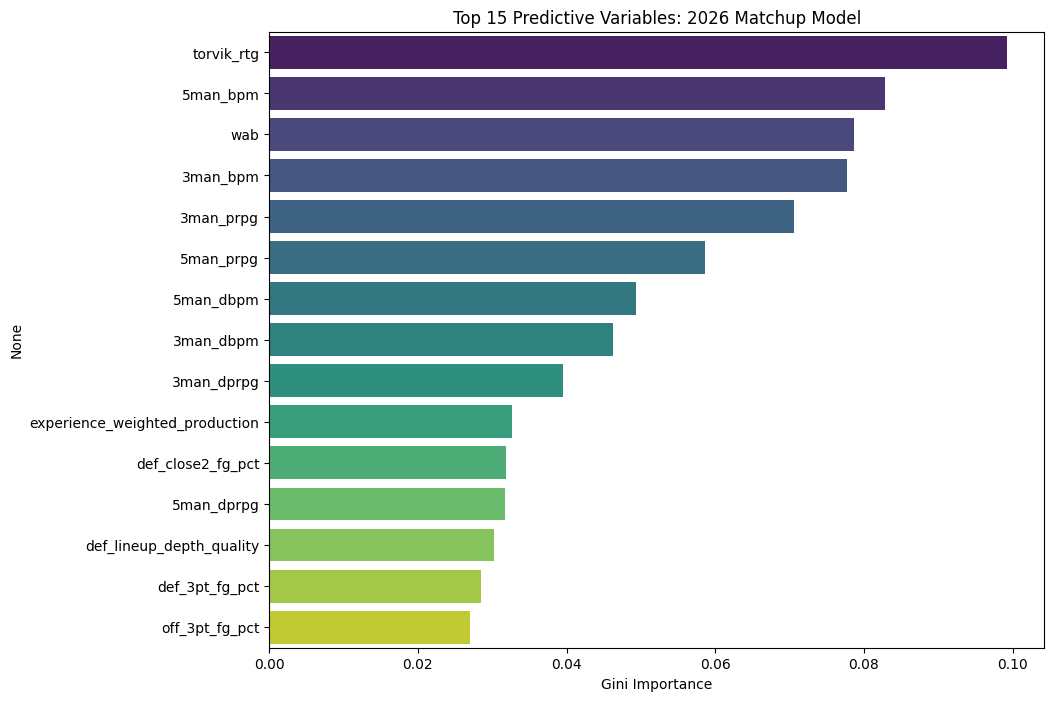

In [11]:
# 1. Re-train the best model using the optimal parameters found by Optuna
best_params = study.best_params
final_rf = RandomForestClassifier(**best_params, random_state=42)
final_rf.fit(X_train_sel, y_train)

# 2. Map feature importance back to the Top 25 selected names
importances = final_rf.feature_importances_
feat_imp = pd.Series(importances, index=selected_names).sort_values(ascending=False)

# 3. Generate Win Probabilities for the Validation Set
# This is the "Heat Map" for your bracket decisions
val_probs = final_rf.predict_proba(X_val_sel)[:, 1]
val_results = pd.DataFrame({
    'Actual_Win': y_val.values,
    'Win_Probability': np.round(val_probs, 3),
    'Prediction': (val_probs > 0.5).astype(int)
})

# 4. Display the Top 15 Most Important Features
print("--- FINAL OPTIMIZED FEATURE IMPORTANCE ---")
print(feat_imp.head(15))

# 5. Display the Validation Games the model found "Difficult" (Coin-flips)
print("\n--- TOUGHEST GAMES TO PREDICT (Probabilities near 50%) ---")
print(val_results[(val_results['Win_Probability'] > 0.45) &
                  (val_results['Win_Probability'] < 0.55)].head(10))

# 6. Final Performance Summary
from sklearn.metrics import log_loss
print(f"\n--- PERFORMANCE METRICS ---")
print(f"Final Validation Accuracy: {accuracy_score(y_val, val_results['Prediction']):.4f}")
print(f"Model Log Loss (Confidence Score): {log_loss(y_val, val_probs):.4f}")

# 7. Visualizing the final Importance
plt.figure(figsize=(10, 8))
sns.barplot(x=feat_imp.head(15).values, y=feat_imp.head(15).index, palette='viridis')
plt.title('Top 15 Predictive Variables: 2026 Matchup Model')
plt.xlabel('Gini Importance')
plt.show()

In [12]:
for key, value in study.best_params.items():
    print(f"{key}: {value}")

n_estimators: 372
max_depth: 8
min_samples_split: 4
min_samples_leaf: 5
ccp_alpha: 5.356757818696768e-06
